
RELATÓRIO DE PERFORMANCE FINAL
+--------------+------------------------+--------------------+------------+-------------+
| Classe       |   Precisão (Confiança) |   Recall (Alcance) |   F1-Score |   Qtd Dados |
|--------------+------------------------+--------------------+------------+-------------|
| 0            |                   0.99 |               0.47 |       0.64 |       31788 |
| 1            |                   0.63 |               1    |       0.77 |       28212 |
| macro avg    |                   0.81 |               0.73 |       0.7  |       60000 |
| weighted avg |                   0.82 |               0.72 |       0.7  |       60000 |
+--------------+------------------------+--------------------+------------+-------------+

Acurácia Geral: 71.85%


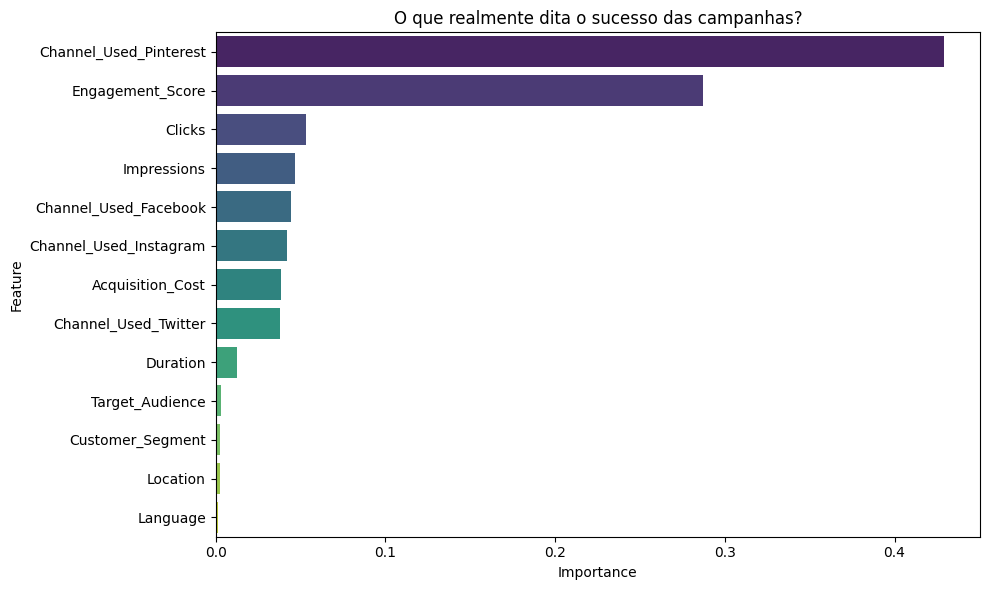

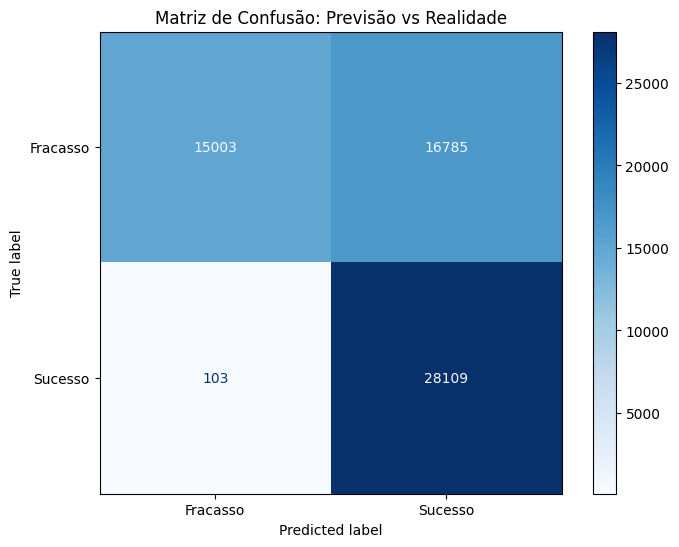

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder
from tabulate import tabulate
import warnings

warnings.simplefilter(action="ignore", category=FutureWarning)

# Carrega os dados do CSV
df = pd.read_csv("Social_Media_Advertising.csv")

# Remove carac especiais e converte para float
df["Acquisition_Cost"] = (
    df["Acquisition_Cost"].str.replace("$", "").str.replace(",", "").astype(float)
)

# Remove carac especiais e converte para int
df["Duration"] = df["Duration"].str.replace(" Days", "").astype(int)

# Codificação de vars categóricas
df = pd.get_dummies(df, columns=["Channel_Used", "Campaign_Goal"])

# Transforma vars categóricas em numéricas
le = LabelEncoder()
for col in ["Target_Audience", "Location", "Language", "Customer_Segment"]:
    df[col] = le.fit_transform(df[col])

# Define a variável alvo
df["Success"] = (df["ROI"] > 3.0).astype(int)

# Define as vars que serão usadas no modelo
features = [
    "Clicks",
    "Impressions",
    "Engagement_Score",
    "Acquisition_Cost",
    "Duration",
    "Target_Audience",
    "Location",
    "Language",
    "Customer_Segment",
]
features += [col for col in df.columns if col.startswith("Channel_Used_")]

# Define as vars independentes (X) e dependente (y)
X = df[features]
y = df["Success"]

# Divide os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Treina o modelo Random Forest
modelo = RandomForestClassifier(
    n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
)
modelo.fit(X_train, y_train)

# Prevê as probabilidades
probabilidades = modelo.predict_proba(X_test)[:, 1]

# Define o limiar (threshold)
limiar = 0.58
previsoes = (probabilidades >= limiar).astype(int)

report = classification_report(y_test, previsoes, output_dict=True, zero_division=0)

tabela_data = []
for label, metrics in report.items():
    if isinstance(metrics, dict):
        tabela_data.append(
            [
                label,
                f"{metrics['precision']:.2f}",
                f"{metrics['recall']:.2f}",
                f"{metrics['f1-score']:.2f}",
                int(metrics["support"]),
            ]
        )

headers = [
    "Classe",
    "Precisão (Confiança)",
    "Recall (Alcance)",
    "F1-Score",
    "Qtd Dados",
]

print("\n" + "=" * 50)
print("RELATÓRIO DE PERFORMANCE FINAL")
print("=" * 50)
print(tabulate(tabela_data, headers=headers, tablefmt="psql"))
print(f"\nAcurácia Geral: {accuracy_score(y_test, previsoes):.2%}")


# Gráfico de importância das vars
importancias = modelo.feature_importances_
feature_imp_df = pd.DataFrame({"Feature": features, "Importance": importancias})
feature_imp_df = feature_imp_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_imp_df,
    hue="Feature",
    palette="viridis",
    legend=False,
)
plt.title("O que realmente dita o sucesso das campanhas?")
plt.tight_layout()
plt.show()

# Matriz de Confusão
cm = confusion_matrix(y_test, previsoes)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["Fracasso", "Sucesso"]
)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", ax=ax)
plt.title("Matriz de Confusão: Previsão vs Realidade")
plt.show()